In [13]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df_raw = pd.read_csv("/content/Base_de_datos_final_Almeraya.xlsx - Datos_crudos.csv")
df = df_raw.copy()

# Inspección inicial
print("=== DIMENSIONES ===")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("=== COLUMNAS Y TIPOS DE DATOS ===")
print(df.dtypes)

print("\n=== PRIMERAS 5 FILAS ===")
df.head()

=== DIMENSIONES ===
Filas: 436, Columnas: 61

=== COLUMNAS Y TIPOS DE DATOS ===
Unnamed: 0                                            object
Nombre completo (apellido_paterno_materno_nombres)    object
no. Expediente                                        object
Fecha INGRESO                                         object
Grado escolar                                         object
                                                       ...  
ICDAS 82                                              object
ICDAS 83                                              object
ICDAS 84                                              object
ICDAS 85                                              object
Unnamed: 60                                           object
Length: 61, dtype: object

=== PRIMERAS 5 FILAS ===


,Unnamed: 0,Nombre completo (apellido_paterno_materno_nombres),no. Expediente,Fecha INGRESO,Grado escolar,Sexo,FEM 1 MAS 2,Edad,Estatura,Peso,...,ICDAS 74,ICDAS 73,ICDAS 72,ICDAS 71,ICDAS 81,ICDAS 82,ICDAS 83,ICDAS 84,ICDAS 85,Unnamed: 60
0,Andrea S,Garcia Parrilla Ana Paula,2306014,9/5/2023,2° Primaria,F,1,8,127,28,...,2,0-0,98,98,98,98,2,3,2,The language entered is not supported at this ...
1,Andrea S,Mayen León Ángel de Jesús,2306013,16/5/2023,3° primaria,M,2,9,125,"28,5",...,98,98,98,98,98,98,98,3,98,NaN
2,Andrea S,Vazquez Sanchez Giovanni Rafael,2305099,17/1/2023,6° Primaria,M,2,11,139,40,...,0-0,0-0,0-0,98,98,98,98,98,98,NaN
3,Andrea S,Quintana Sánchez Israel Abimael,2305095,31/1/2023,6° Primaria,M,2,11,147,47,...,98,98,98,98,98,98,98,98,0-0,NaN
4,Andrea S,Quintana Sánchez Jania Camila,2305098,31/1/2023,E. Temprana,F,1,2,95,"13,9",...,0-0,0-0,0-0,0-0,0-0,0-0,0-0,0-0,0-0,NaN


# Limpia y normalización de estructura

In [15]:
#Eliminar columnas innecesarias detectadas en la inspección
cols_a_eliminar = [c for c in df.columns if "Unnamed" in c]
df = df.drop(columns=cols_a_eliminar)

# Normalizar nombres de columnas (minusculas, sin espacios al inicio/final, guiones bajos)
df.columns = (
    df.columns.str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace(".", "")
    .str.replace("(", "")
    .str.replace(")", "")
)

# Limpieza de variables somatométricas (Edad, Peso, Estatura)
# Reemplazamos la coma decimal por punto y forzamos la conversión a numérico
cols_numericas = ["edad", "estatura", "peso"]

for col in cols_numericas:
    if col in df.columns:
        # Convertimos a string, reemplazamos comas y convertimos a número (los errores se vuelven NaN)
        df[col] = df[col].astype(str).str.replace(",", ".")
        df[col] = pd.to_numeric(df[col], errors="coerce")

# 4. Limpieza básica de la Fecha de Ingreso
if "fecha_ingreso" in df.columns:
    df["fecha_ingreso"] = pd.to_datetime(
        df["fecha_ingreso"], errors="coerce", dayfirst=True
    )

# 5. Verificación del estado de salud pos-limpieza
print("=== NUEVAS DIMENSIONES ===")
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}\n")

print("=== VERIFICACIÓN DE TIPOS CONVERTIDOS ===")
print(df[["edad", "estatura", "peso", "fecha_ingreso"]].dtypes)

print("\n=== RESUMEN ESTADÍSTICO INICIAL (BIOMETRÍA) ===")
print(df[["edad", "estatura", "peso"]].describe().T)

=== NUEVAS DIMENSIONES ===
Filas: 436, Columnas: 59

=== VERIFICACIÓN DE TIPOS CONVERTIDOS ===
edad                      int64
estatura                float64
peso                    float64
fecha_ingreso    datetime64[ns]
dtype: object

=== RESUMEN ESTADÍSTICO INICIAL (BIOMETRÍA) ===
          count        mean        std   min    25%    50%    75%    max
edad      436.0    7.800459   3.351322  1.00    5.0    7.5   10.0   17.0
estatura  394.0  123.640076  22.650117  1.58  110.0  122.0  138.0  173.0
peso      411.0   29.134063  14.048477  1.00   19.0   25.0   37.0   82.0


In [16]:
df_clean = df.copy()
# 1. Corrección de Estatura (Convertir metros a centímetros cuando estatura < 3.0)
df_clean["estatura_cm"] = df_clean["estatura"].apply(
    lambda x: x * 100 if (pd.notnull(x) and x < 3.0) else x
)

# 2. Tratamiento de Errores de Captura en Peso (Peso < 5 kg se considera invalido/NaN)
df_clean["peso_kg"] = df_clean["peso"].apply(
    lambda x: np.nan if (pd.notnull(x) and x < 5.0) else x
)

# 3. Feature Engineering: Cálculo del IMC (Índice de Masa Corporal)
# Formula: peso / (estatura_m)^2
df_clean["imc"] = df_clean["peso_kg"] / ((df_clean["estatura_cm"] / 100) ** 2)

# 4. Generación del reporte corregido
cols_biometria = ["edad", "estatura_cm", "peso_kg", "imc"]

print("=== RESUMEN ESTADÍSTICO CORREGIDO Y LIMPIO ===")
resumen_limpio = df_clean[cols_biometria].describe().T
resumen_limpio["median"] = df_clean[cols_biometria].median()
print(resumen_limpio[["count", "mean", "std", "min", "50%", "max"]])

=== RESUMEN ESTADÍSTICO CORREGIDO Y LIMPIO ===
             count        mean        std        min         50%         max
edad         436.0    7.800459   3.351322   1.000000    7.500000   17.000000
estatura_cm  394.0  124.441624  21.050839  45.000000  123.000000  173.000000
peso_kg      409.0   29.266748  13.953333  10.000000   25.000000   82.000000
imc          391.0   18.119485   4.888256   5.190311   17.360035   49.382716


In [17]:
# Continuamos sobre nuestra copia saneada
df_analisis = df_clean.copy()

# 1. Identificar registros con IMC inverosímil (< 10)
anomalias_imc = df_analisis[df_analisis["imc"] < 10][
    ["edad", "estatura_cm", "peso_kg", "imc"]
]
print("=== REGISTROS CON ANOMALÍAS ANTROPOMÉTRICAS (< 10 IMC) ===")
print(anomalias_imc)
print("-" * 50)

# 2. Corrección: Reemplazar por NaN valores de IMC < 10 por considerarse error de captura
df_analisis.loc[df_analisis["imc"] < 10, ["estatura_cm", "peso_kg", "imc"]] = (
    np.nan
)


# 3. Categorización simplificada de salud nutricional por IMC
def categorizar_imc(imc):
    if pd.isna(imc):
        return "Sin dato"
    elif imc < 14.0:
        return "Bajo peso severo"
    elif 14.0 <= imc < 18.5:
        return "Peso saludable / Normal"
    elif 18.5 <= imc < 22.0:
        return "Sobrepeso"
    else:
        return "Obesidad / Riesgo elevado"


df_analisis["categoria_imc"] = df_analisis["imc"].apply(categorizar_imc)

# 4. Mapeo del Módulo ICDAS
cols_icdas = [col for col in df_analisis.columns if "icdas" in col.lower()]

print("=== RESUMEN DEL MÓDULO ICDAS ===")
print(f"Total de dientes/superficies evaluadas (Columnas ICDAS): {len(cols_icdas)}")
print(f"Muestra de columnas ICDAS: {cols_icdas[:10]}")
print("\n=== DISTRIBUCIÓN DE CATEGORÍAS NUTRICIONALES ===")
print(df_analisis["categoria_imc"].value_counts(dropna=False))

=== REGISTROS CON ANOMALÍAS ANTROPOMÉTRICAS (< 10 IMC) ===
     edad  estatura_cm  peso_kg       imc
16      4        105.0     10.4  9.433107
219     5        170.0     15.0  5.190311
229     4        150.0     16.0  7.111111
301     4        128.0     15.0  9.155273
353     3        117.0     13.0  9.496676
--------------------------------------------------
=== RESUMEN DEL MÓDULO ICDAS ===
Total de dientes/superficies evaluadas (Columnas ICDAS): 48
Muestra de columnas ICDAS: ['icdas_17', 'icdas_16', 'icdas_15', 'icdas_14', 'icdas__13', 'icdas_12', 'icdas_11', 'icdas_21', 'icdas_22', 'icdas_23']

=== DISTRIBUCIÓN DE CATEGORÍAS NUTRICIONALES ===
categoria_imc
Peso saludable / Normal      181
Sobrepeso                     94
Obesidad / Riesgo elevado     59
Bajo peso severo              52
Sin dato                      50
Name: count, dtype: int64


In [18]:
# Trabajamos sobre nuestra copia
df_icdas = df_analisis.copy()

# 1. Reclasificar anomalías de IMC a 'Sin dato' en la variable categórica
df_icdas.loc[df_icdas["imc"] < 10, "categoria_imc"] = "Sin dato"

# 2. Identificar columnas ICDAS
cols_icdas = [c for c in df_icdas.columns if "icdas" in c.lower()]


# 3. Limpieza sintáctica celda por celda
def limpiar_icdas_celda(val):
    if pd.isna(val):
        return np.nan
    val_str = str(val).strip()

    # Si viene en formato compuesto ('0-0', '2-1'), tomar el valor máximo de severidad
    if "-" in val_str:
        partes = [int(p) for p in val_str.split("-") if p.isdigit()]
        return max(partes) if partes else np.nan

    if val_str.isdigit():
        return int(val_str)

    return np.nan


# Aplicar limpieza a todas las columnas de la dentición
for col in cols_icdas:
    df_icdas[col] = df_icdas[col].apply(limpiar_icdas_celda)


# 4. Feature Engineering por Paciente
def calcular_metricas_dentales(row):
    valores = row[cols_icdas].dropna()

    if len(valores) == 0:
        return pd.Series([0, 0, np.nan, np.nan])

    # Filtrar dientes ausentes (código 98)
    presentes = valores[valores != 98]

    if len(presentes) == 0:
        return pd.Series([0, 0, np.nan, np.nan])

    dientes_evaluados = len(presentes)
    dientes_caries = (presentes >= 1).sum()
    max_icdas = presentes.max()
    prom_icdas = presentes.mean()

    return pd.Series(
        [dientes_evaluados, dientes_caries, max_icdas, round(prom_icdas, 2)]
    )


# Asignar nuevas columnas
metricas_df = df_icdas.apply(calcular_metricas_dentales, axis=1)
metricas_df.columns = [
    "total_dientes_evaluados",
    "dientes_con_caries",
    "icdas_maximo",
    "icdas_promedio",
]

df_icdas = pd.concat([df_icdas, metricas_df], axis=1)

# 5. Reporte Estadístico de Control
print("=== RESUMEN EJECUTIVO DE CARIES Y NUTRICIÓN ===")
print(
    f"Prevalencia General de Caries (ICDAS >= 1): {(df_icdas['dientes_con_caries'] > 0).mean() * 100:.1f}%"
)
print(
    f"Promedio de piezas evaluadas por paciente: {df_icdas['total_dientes_evaluados'].mean():.1f}"
)
print(
    f"Promedio de piezas lesionadas por paciente: {df_icdas['dientes_con_caries'].mean():.1f}\n"
)

print("=== SEVERIDAD MÁXIMA DETECTADA (DISTRIBUCIÓN DE PACIENTES) ===")
print(df_icdas["icdas_maximo"].value_counts(dropna=False).sort_index())

print("\n=== DISTRIBUCIÓN NUTRICIONAL REAJUSTADA ===")
print(df_icdas["categoria_imc"].value_counts(dropna=False))

=== RESUMEN EJECUTIVO DE CARIES Y NUTRICIÓN ===
Prevalencia General de Caries (ICDAS >= 1): 100.0%
Promedio de piezas evaluadas por paciente: 44.3
Promedio de piezas lesionadas por paciente: 34.4

=== SEVERIDAD MÁXIMA DETECTADA (DISTRIBUCIÓN DE PACIENTES) ===
icdas_maximo
1.0       1
3.0       6
4.0       1
5.0       3
6.0       4
9.0      10
10.0      1
13.0      1
20.0      1
30.0      1
32.0      1
33.0      1
43.0      1
70.0      3
73.0      1
74.0      1
80.0      2
96.0      2
97.0      2
99.0    393
Name: count, dtype: int64

=== DISTRIBUCIÓN NUTRICIONAL REAJUSTADA ===
categoria_imc
Peso saludable / Normal      181
Sobrepeso                     94
Obesidad / Riesgo elevado     59
Bajo peso severo              52
Sin dato                      50
Name: count, dtype: int64


In [19]:
df_corregido = df_analisis.copy()
cols_icdas = [c for c in df_corregido.columns if "icdas" in c.lower()]

# 1. AUDITORÍA: Ver qué valores existen realmente en toda la matriz ICDAS
valores_unicos_raw = set()
for col in cols_icdas:
    valores_unicos_raw.update(df_corregido[col].dropna().unique())

print("=== VALORES ÚNICOS DETECTADOS EN LAS COLUMNAS ICDAS ===")
print(sorted(list(valores_unicos_raw)))
print("-" * 60)


# 2. FUNCIÓN DE EXTRACCIÓN CLÍNICA RIGUROSA (Solo ICDAS 0 a 6)
def extraer_icdas_clinico(val):
    if pd.isna(val):
        return np.nan

    val_str = str(val).strip()

    # Si es una cadena con guion (ej. '2-0', '1-2'), evaluamos cada parte
    if "-" in val_str:
        partes = [int(p) for p in val_str.split("-") if p.isdigit()]
        # Filtramos solo valores clínicos válidos (0 a 6)
        partes_validas = [p for p in partes if 0 <= p <= 6]
        return max(partes_validas) if partes_validas else np.nan

    # Si es un número directo
    try:
        num = float(val_str)
        if 0 <= num <= 6:
            return int(num)
        else:
            # Los valores >= 7 (como 98, 99, 70, 80) son códigos administrativos/ausencias
            return np.nan
    except ValueError:
        return np.nan


# Crear DataFrame aislado solo con evaluaciones clínicas válidas
df_icdas_clean = pd.DataFrame(index=df_corregido.index)

for col in cols_icdas:
    df_icdas_clean[col] = df_corregido[col].apply(extraer_icdas_clinico)


# 3. RECALCULAR MÉTRICAS CLÍNICAS REALES
def calcular_salud_oral_real(row):
    # Tomamos solo los dientes que tienen una lectura clínica válida (0 a 6)
    dientes_validos = row.dropna()

    total_evaluados = len(dientes_validos)
    if total_evaluados == 0:
        return pd.Series([0, 0, np.nan, np.nan])

    # Caries real es ICDAS entre 1 y 6
    dientes_con_caries = (dientes_validos >= 1).sum()
    max_icdas = dientes_validos.max()
    prom_icdas = dientes_validos.mean()

    return pd.Series(
        [
            total_evaluados,
            dientes_con_caries,
            max_icdas,
            round(prom_icdas, 2),
        ]
    )


metricas_reales = df_icdas_clean.apply(calcular_salud_oral_real, axis=1)
metricas_reales.columns = [
    "dientes_evaluados_real",
    "dientes_caries_real",
    "icdas_max_real",
    "icdas_prom_real",
]

# Unimos de nuevo al DataFrame principal
df_corregido = pd.concat([df_corregido, metricas_reales], axis=1)

# 4. REPORTE DE CONTROL DE CALIDAD
print("=== RESUMEN EJECUTIVO DE SALUD ORAL (DATOS CORREGIDOS) ===")
pacientes_con_datos = (df_corregido["dientes_evaluados_real"] > 0).sum()
print(
    f"Pacientes con registros dentales válidos: {pacientes_con_datos} / {len(df_corregido)}"
)
print(
    f"Promedio de dientes reales evaluados por paciente: {df_corregido['dientes_evaluados_real'].mean():.1f}"
)
print(
    f"Promedio de dientes lesionados por paciente: {df_corregido['dientes_caries_real'].mean():.1f}"
)

# Prevalencia real calculada solo sobre pacientes con evaluación válida
prevalencia_real = (
    df_corregido[df_corregido["dientes_evaluados_real"] > 0][
        "dientes_caries_real"
    ]
    > 0
).mean() * 100
print(f"Prevalencia REAL de Caries (ICDAS >= 1): {prevalencia_real:.1f}%\n")

print("=== DISTRIBUCIÓN DE SEVERIDAD MÁXIMA REAL (ICDAS 0 A 6) ===")
print(df_corregido["icdas_max_real"].value_counts(dropna=False).sort_index())

=== VALORES ÚNICOS DETECTADOS EN LAS COLUMNAS ICDAS ===
['0', '0,3', '0-', '0--2', '0-0', '0-1', '0-2', '0-3', '0-4', '0-5', '0-6', '00', '01', '02', '03', '04', '05', '06', '09', '1', '10', '11', '12', '13', '15', '17', '2', '20', '22', '23', '24', '3', '3-0', '30', '31', '32', '33', '34', '35', '36', '4', '40', '41', '42', '43', '44', '45', '5', '5-0', '50', '51', '52', '55', '6', '6-0', '60', '65', '67', '7', '70', '72', '73', '74', '75', '76', '8', '80', '82', '84', '85', '86', '9', '9-0', '96', '97', '98', '99']
------------------------------------------------------------
=== RESUMEN EJECUTIVO DE SALUD ORAL (DATOS CORREGIDOS) ===
Pacientes con registros dentales válidos: 436 / 436
Promedio de dientes reales evaluados por paciente: 21.5
Promedio de dientes lesionados por paciente: 11.6
Prevalencia REAL de Caries (ICDAS >= 1): 98.9%

=== DISTRIBUCIÓN DE SEVERIDAD MÁXIMA REAL (ICDAS 0 A 6) ===
icdas_max_real
0.0      5
1.0      2
2.0     32
3.0     72
4.0     26
5.0     93
6.0    206

In [20]:
# Trabajamos sobre el DataFrame corregido con biometría e ICDAS limpios
df_final = df_corregido.copy()

# 1. Agrupar la Severidad ICDAS en Niveles Clínicos Manejables
# 0: Sano | 1-2: Inicial | 3-4: Moderado | 5-6: Severo
def clasificar_severidad_icdas(val):
    if pd.isna(val):
        return "Sin evaluación"
    elif val == 0:
        return "1. Sano (ICDAS 0)"
    elif val in [1, 2]:
        return "2. Inicial (ICDAS 1-2)"
    elif val in [3, 4]:
        return "3. Moderado (ICDAS 3-4)"
    elif val in [5, 6]:
        return "4. Severo (ICDAS 5-6)"
    return "Sin evaluación"


df_final["nivel_caries"] = df_final["icdas_max_real"].apply(
    clasificar_severidad_icdas
)

# 2. Tabla de Contingencia: Categoria IMC vs Nivel de Caries
# Excluimos pacientes 'Sin dato' para mantener rigor estadístico
mask_validos = (df_final["categoria_imc"] != "Sin dato") & (
    df_final["nivel_caries"] != "Sin evaluación"
)
df_analisis_stats = df_final[mask_validos]

tabla_contingencia = pd.crosstab(
    df_analisis_stats["categoria_imc"],
    df_analisis_stats["nivel_caries"],
    margins=True,
)

print("=== TABLA DE CONTINGENCIA: ESTADO NUTRICIONAL VS SEVERIDAD DE CARIES ===")
print(tabla_contingencia)
print("-" * 70)

# 3. Prueba Estadística de Chi-Cuadrado (χ²)
chi2, p_val, dof, expected = chi2_contingency(
    pd.crosstab(
        df_analisis_stats["categoria_imc"], df_analisis_stats["nivel_caries"]
    )
)

# Cálculo de V de Cramér (Fuerza de Asociación)
n = len(df_analisis_stats)
min_dim = min(
    pd.crosstab(
        df_analisis_stats["categoria_imc"], df_analisis_stats["nivel_caries"]
    ).shape
) - 1
v_cramer = np.sqrt(chi2 / (n * min_dim))

print("=== PRUEBA DE HIPÓTESIS ESTADÍSTICA ===")
print(f"Estadístico Chi-cuadrado (χ²): {chi2:.4f}")
print(f"Grados de Libertad: {dof}")
print(f"p-value: {p_val:.4e}")
print(f"V de Cramér (Efecto): {v_cramer:.4f}")

if p_val < 0.05:
    print(
        "--> CONCLUSIÓN ESTADÍSTICA: Existe una asociación estadísticamente significativa (p < 0.05) entre el IMC y la severidad de caries."
    )
else:
    print(
        "--> CONCLUSIÓN ESTADÍSTICA: No se detecta una asociación lineal/categórica estadísticamente significativa (p >= 0.05) en la muestra."
    )

# 4. Matriz de Priorización Operativa para la Clínica (Segmentación)
def asignar_prioridad_clinica(row):
    icdas = row["icdas_max_real"]
    imc_cat = row["categoria_imc"]

    if icdas in [5, 6]:
        return "P1 - URGENCIA OPERATORIA (Caries Severa)"
    elif icdas in [3, 4] or imc_cat in [
        "Bajo peso severo",
        "Obesidad / Riesgo elevado",
    ]:
        return "P2 - INTERVENCIÓN MODERADA / TRATAMIENTO COMBINADO"
    else:
        return "P3 - PREVENCIÓN Y SEGUIMIENTO REGULAR"


df_final["prioridad_atencion"] = df_final.apply(
    asignar_prioridad_clinica, axis=1
)

print("\n=== DISTRIBUCIÓN DE PACIENTES POR PRIORIDAD DE ATENCIÓN ===")
print(df_final["prioridad_atencion"].value_counts(ascending=False))

=== TABLA DE CONTINGENCIA: ESTADO NUTRICIONAL VS SEVERIDAD DE CARIES ===
nivel_caries               1. Sano (ICDAS 0)  2. Inicial (ICDAS 1-2)  \
categoria_imc                                                          
Bajo peso severo                           0                       5   
Obesidad / Riesgo elevado                  2                       7   
Peso saludable / Normal                    2                      12   
Sobrepeso                                  1                       5   
All                                        5                      29   

nivel_caries               3. Moderado (ICDAS 3-4)  4. Severo (ICDAS 5-6)  All  
categoria_imc                                                                   
Bajo peso severo                                 3                     44   52  
Obesidad / Riesgo elevado                       21                     29   59  
Peso saludable / Normal                         41                    126  181  
Sobrepeso        

/tmp/ipykernel_1031/2644601803.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


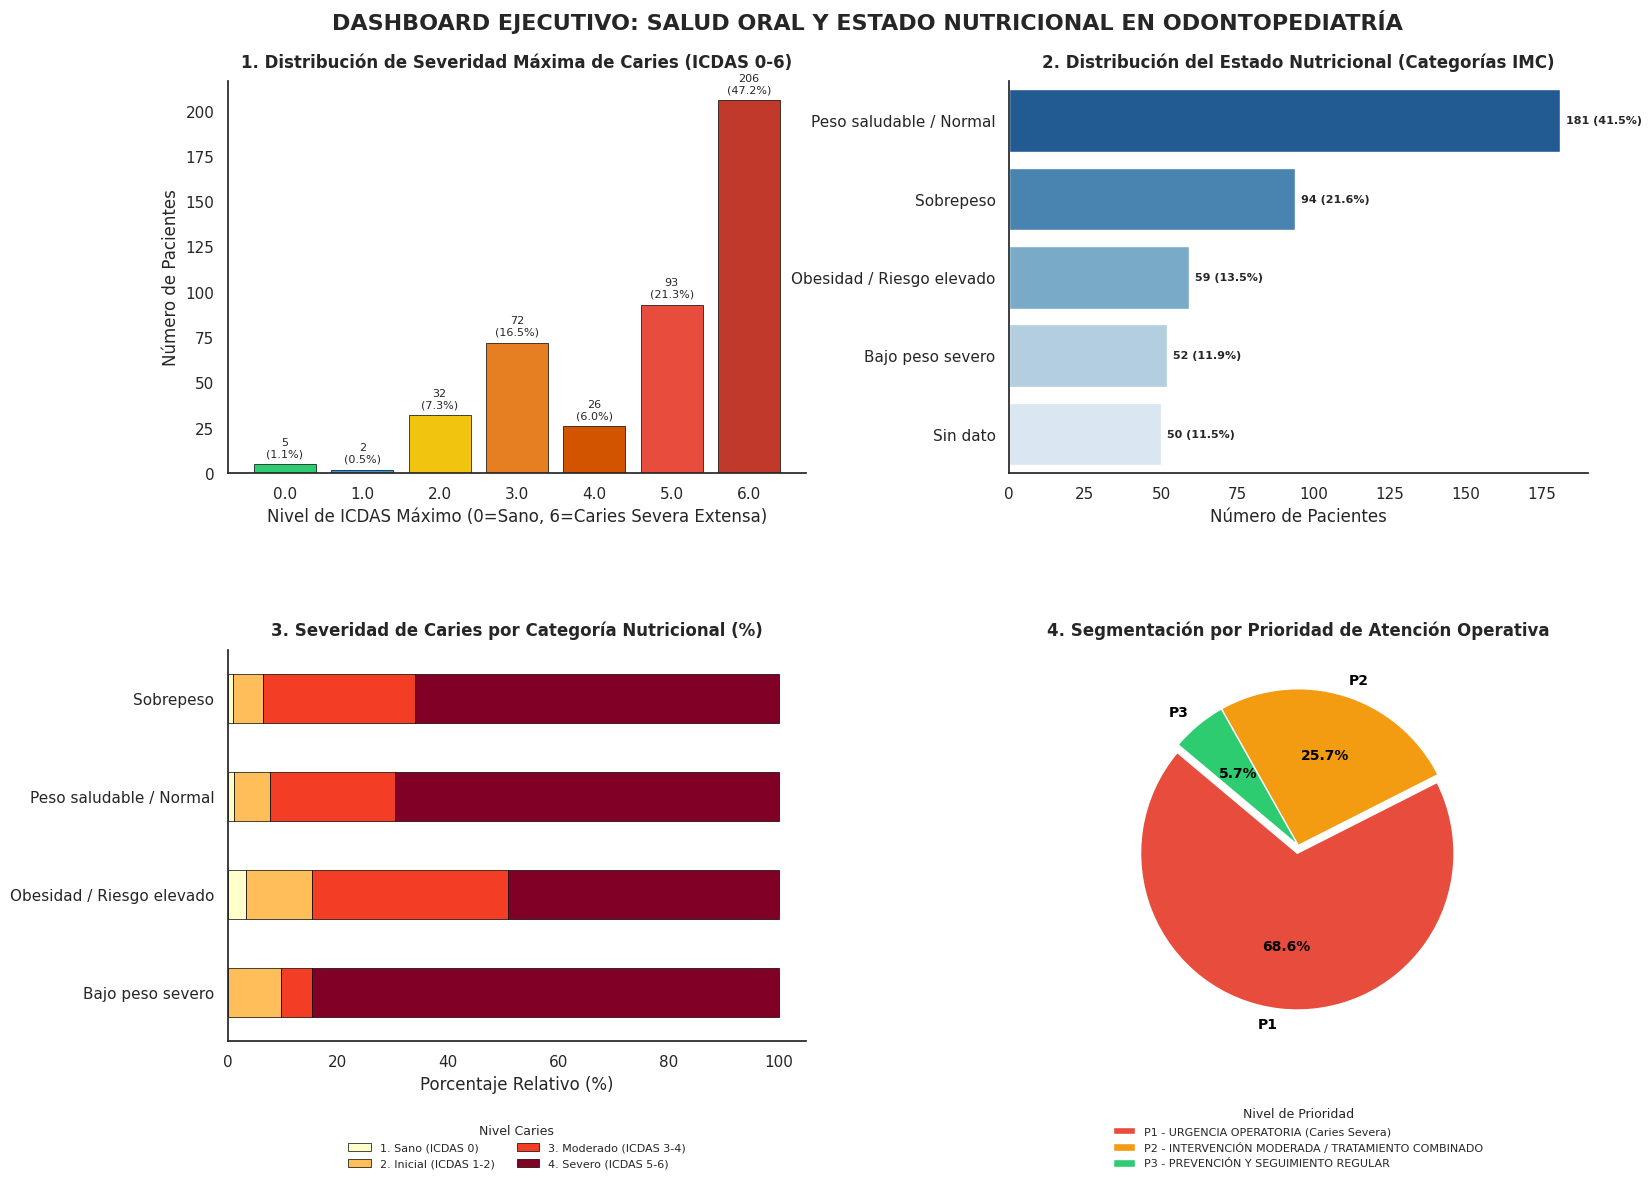

In [21]:
# Estilo global limpio
sns.set_theme(style="white", palette="muted")
plt.rcParams["font.family"] = "sans-serif"

# Crear figura con espacio extendido
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    "DASHBOARD EJECUTIVO: SALUD ORAL Y ESTADO NUTRICIONAL EN ODONTOPEDIATRÍA",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

# -----------------------------------------------------------------------------
# PANEL 1: Distribución de Severidad Máxima de Caries (ICDAS)
# -----------------------------------------------------------------------------
ax1 = axes[0, 0]
icdas_counts = df_final["icdas_max_real"].value_counts().sort_index()
colores_icdas = [
    "#2ecc71",
    "#3498db",
    "#f1c40f",
    "#e67e22",
    "#d35400",
    "#e74c3c",
    "#c0392b",
]

bars1 = ax1.bar(
    icdas_counts.index.astype(str),
    icdas_counts.values,
    color=colores_icdas[: len(icdas_counts)],
    edgecolor="black",
    linewidth=0.5,
)
ax1.set_title(
    "1. Distribución de Severidad Máxima de Caries (ICDAS 0-6)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax1.set_xlabel("Nivel de ICDAS Máximo (0=Sano, 6=Caries Severa Extensa)")
ax1.set_ylabel("Número de Pacientes")
ax1.spines[["top", "right"]].set_visible(False)

for bar in bars1:
    yval = bar.get_height()
    pct = (yval / len(df_final)) * 100
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 3,
        f"{int(yval)}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=8,
    )

# -----------------------------------------------------------------------------
# PANEL 2: Perfil Nutricional (Categorías IMC)
# -----------------------------------------------------------------------------
ax2 = axes[0, 1]
orden_imc = [
    "Peso saludable / Normal",
    "Sobrepeso",
    "Obesidad / Riesgo elevado",
    "Bajo peso severo",
    "Sin dato",
]
imc_counts = df_final["categoria_imc"].value_counts().reindex(orden_imc)

sns.barplot(
    x=imc_counts.values,
    y=imc_counts.index,
    ax=ax2,
    palette="Blues_r",
    orient="h",
)
ax2.set_title(
    "2. Distribución del Estado Nutricional (Categorías IMC)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax2.set_xlabel("Número de Pacientes")
ax2.set_ylabel("")
ax2.spines[["top", "right"]].set_visible(False)

for i, val in enumerate(imc_counts.values):
    if not np.isnan(val):
        pct = (val / len(df_final)) * 100
        ax2.text(
            val + 2,
            i,
            f"{int(val)} ({pct:.1f}%)",
            va="center",
            ha="left",
            fontsize=8,
            fontweight="bold",
        )

# -----------------------------------------------------------------------------
# PANEL 3: Matriz Nutrición vs. Severidad de Caries (Comorbilidad)
# -----------------------------------------------------------------------------
ax3 = axes[1, 0]
mask_val = (df_final["categoria_imc"] != "Sin dato") & (
    df_final["nivel_caries"] != "Sin evaluación"
)
ct = pd.crosstab(
    df_final[mask_val]["categoria_imc"],
    df_final[mask_val]["nivel_caries"],
    normalize="index",
) * 100

ct.plot(
    kind="barh",
    stacked=True,
    ax=ax3,
    colormap="YlOrRd",
    edgecolor="black",
    linewidth=0.5,
)
ax3.set_title(
    "3. Severidad de Caries por Categoría Nutricional (%)",
    fontsize=12,
    fontweight="bold",
    pad=10,
)
ax3.set_xlabel("Porcentaje Relativo (%)")
ax3.set_ylabel("")
ax3.spines[["top", "right"]].set_visible(False)

# Ubicación de leyenda ajustada para evitar colisiones
ax3.legend(
    title="Nivel Caries",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=2,
    fontsize=8,
    title_fontsize=9,
    frameon=False,
)

# -----------------------------------------------------------------------------
# PANEL 4: Triaje Operativo / Prioridad de Atención Clínica
# -----------------------------------------------------------------------------
ax4 = axes[1, 1]
prio_counts = df_final["prioridad_atencion"].value_counts()
colores_prio = ["#e74c3c", "#f39c12", "#2ecc71"]

wedges, texts, autotexts = ax4.pie(
    prio_counts.values,
    labels=["P1", "P2", "P3"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colores_prio,
    explode=(0.05, 0, 0),
    textprops=dict(color="black", fontweight="bold", fontsize=10),
)
ax4.set_title(
    "4. Segmentación por Prioridad de Atención Operativa",
    fontsize=12,
    fontweight="bold",
    pad=10,
)

# Leyenda reposicionada debajo del gráfico
ax4.legend(
    wedges,
    prio_counts.index,
    title="Nivel de Prioridad",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    fontsize=8,
    title_fontsize=9,
    frameon=False,
)

# Control fino de márgenes y espacios entre subplots
plt.subplots_adjust(
    left=0.1, right=0.95, top=0.92, bottom=0.12, wspace=0.35, hspace=0.45
)

plt.show()

In [22]:
# Exportar a CSV asegurando la codificación UTF-8 y sin incluir el índice numérico
df_clean.to_csv("dataset_limpio.csv", index=False, encoding="utf-8")
print("Base de datos limpia guardada exitosamente como 'dataset_limpio.csv'.")

Base de datos limpia guardada exitosamente como 'dataset_limpio.csv'.
